# Разработка A/B-тестирования и анализ результатов
## Введение
Компания разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Необходимо рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

Задачи:
- рассчитать параметры теста,
- оценить корректность его проведения,
- проанализировать результаты эксперимента.

## Описание данных

Данные содержат три таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

## Содержание проекта
1. [Работа с историческими данными (EDA)](#работа)
2. [Подготовка к тесту](#подготовка)
3. [Мониторинг А/В-теста](#мониторинг)
4. [Проверка результатов A/B-теста](#проверка)
5. [Вывод по результатам A/B-эксперимента](#вывод)

<a id="работа"></a>
## 1 Работа с историческими данными (EDA)

### 1.1 Загрузка данных
Загрузим все необходимые для проекта библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

Загрузим CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv` и изучим их.

In [2]:
sessions_history = pd.read_csv('sessions_project_history.csv')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


### 1.2 Знакомство с данными
Изучим таблицу для пользователя с наибольшим количеством уникальных сессий, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
unique_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
max_user_id = unique_sessions.idxmax()
sessions_history[sessions_history['user_id'] == max_user_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### 1.3 Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь будем считать зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог метрики DAU, но для регистраций пользователей).

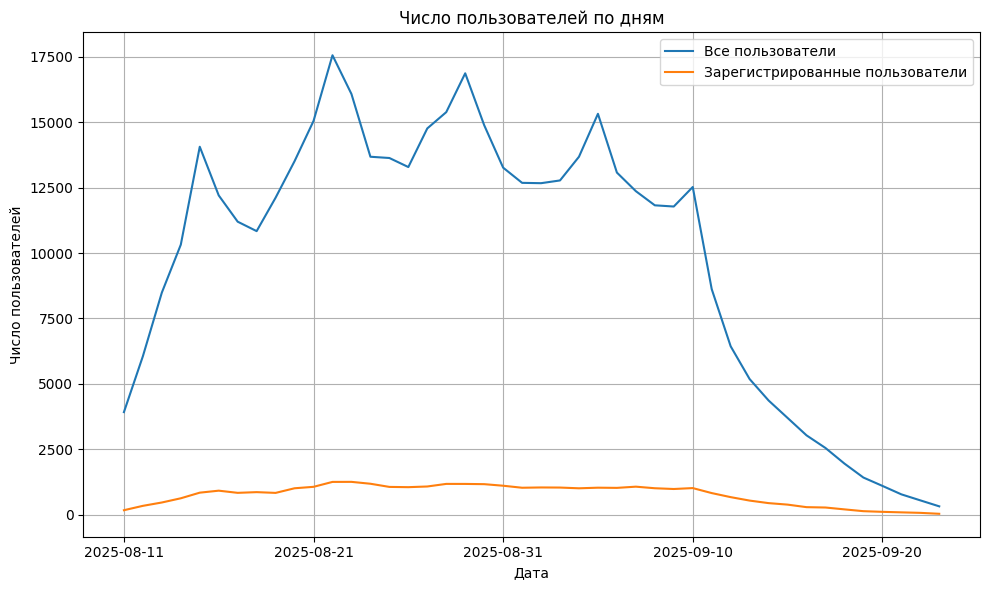

In [5]:
unique_users = sessions_history.groupby('session_date')['user_id'].nunique()
reg_users = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

plt.figure(figsize=(10, 6))

unique_users.plot(
    kind='line',
    label='Все пользователи'
)
reg_users.plot(
    kind='line',
    label='Зарегистрированные пользователи'
)

plt.title('Число пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Число пользователей')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Как мы видим, к середине августа 2025 общее количество пользователей увеличилось на 10 тыс. по сравнению с 11 августа, с которого начинается временной ряд.

Далее виден небольшой возрастающий тренд. Вместе с этим можно заметить всплески активности, начинающиеся каждый чт и заканчивающиеся к пн, что вполне логично - на выходных у людей появляется свободное время для развлечений.

Однако, также можем видеть уменьшение числа пользователей после 10 сентября, что приводит к количеству пользователей менее 2500 уже в 20х числах сентября.

Количество зарегистрированных пользователей повторяет поведение общего числа пользователей на протяжении всего периода наблюдения.

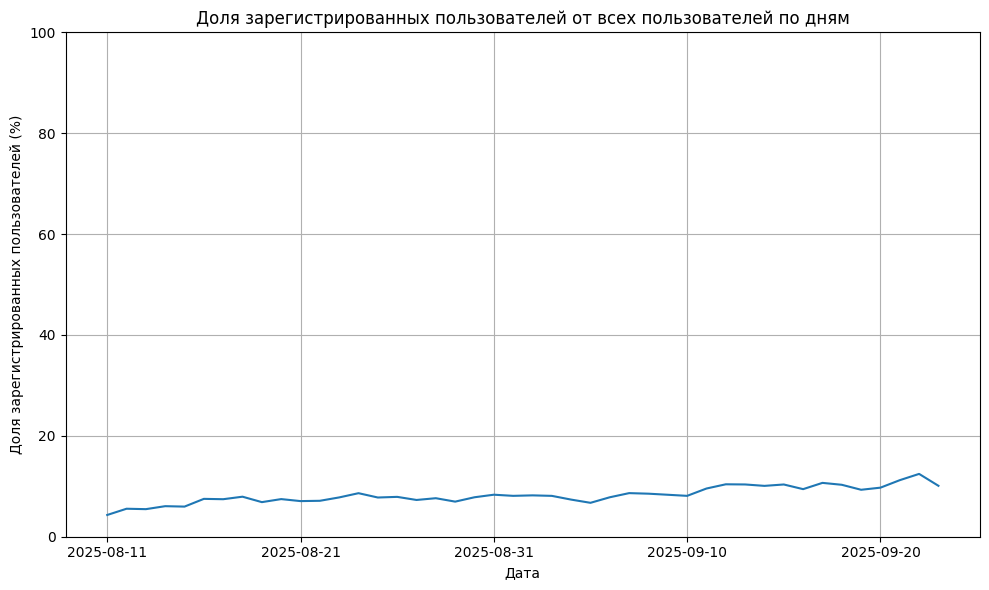

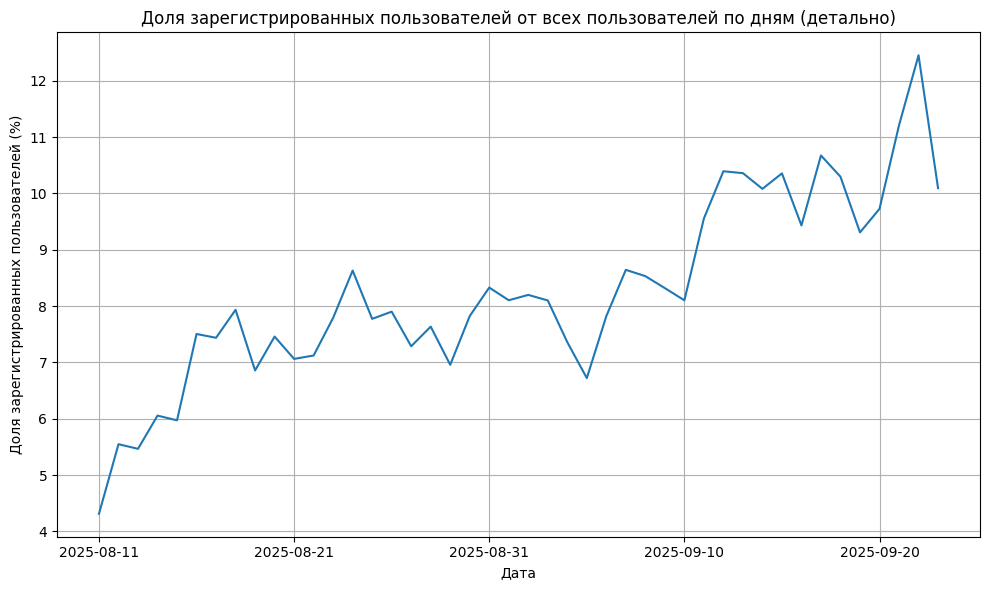

In [6]:
share_of_registered = (reg_users / unique_users) * 100

def plot_share(limit_y=True):
    plt.figure(figsize=(10, 6))
    share_of_registered.plot(kind='line')
    plt.xlabel('Дата')
    plt.ylabel('Доля зарегистрированных пользователей (%)')
    plt.grid(True)
    if limit_y:
        plt.ylim(0, 100)
        plt.title('Доля зарегистрированных пользователей от всех пользователей по дням')
    else:
        plt.title('Доля зарегистрированных пользователей от всех пользователей по дням (детально)')
    plt.tight_layout()
    plt.show()

# График с ограничением по оси Y, чтобы не искажать данные
plot_share(limit_y=True)

# График без ограничения для более детального представления
plot_share(limit_y=False)

Несмотря на то, что количество пользователей колеблется на протяжении всего периода наблюдения, доля зарегистрированных пользователей обладает возрастающим трендом и растет с 4.5% в начале исследования до 10% в конце исследования.

### 1.4 Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку. Проанализируем число просмотренных страниц во время первых сессий пользователей.

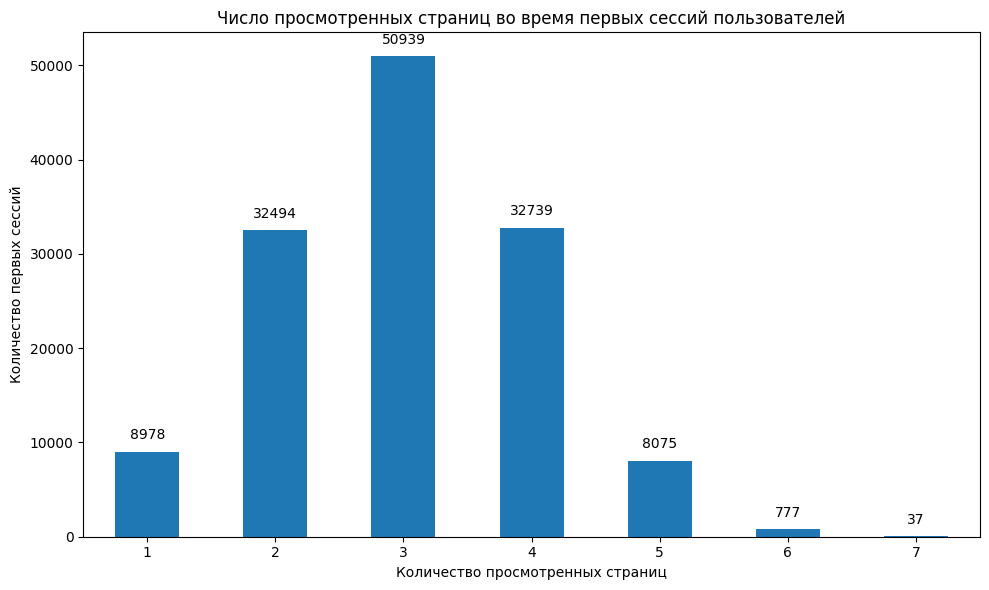

In [7]:
total_pages = sessions_history[sessions_history['session_number'] == 1].groupby('page_counter')['session_id'].count()
plt.figure(figsize=(10, 6))
ax = total_pages.plot(kind='bar',
                      title='Число просмотренных страниц во время первых сессий пользователей',
                      xlabel='Количество просмотренных страниц',
                      ylabel='Количество первых сессий',
                      rot=0)

for i, v in enumerate(total_pages.values):
    ax.text(i, v + max(total_pages.values) * 0.02,
            str(v),
            ha='center',
            va='bottom')

plt.tight_layout()
plt.show()

Самое распространенное количество просмотренных страниц - 3 (около 50 тыс сессий). Далее идут 2 и 4 (по 32 тыс), 1 и 5 (менее 9 тыс), 6 и 7 (менее 1 тыс).

### 1.5 Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта. 

В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

In [8]:
sessions_history['good_session'] = sessions_history['page_counter'].apply(lambda x: 1 if x >= 4 else 0)

Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализируем по дням за весь период наблюдения.

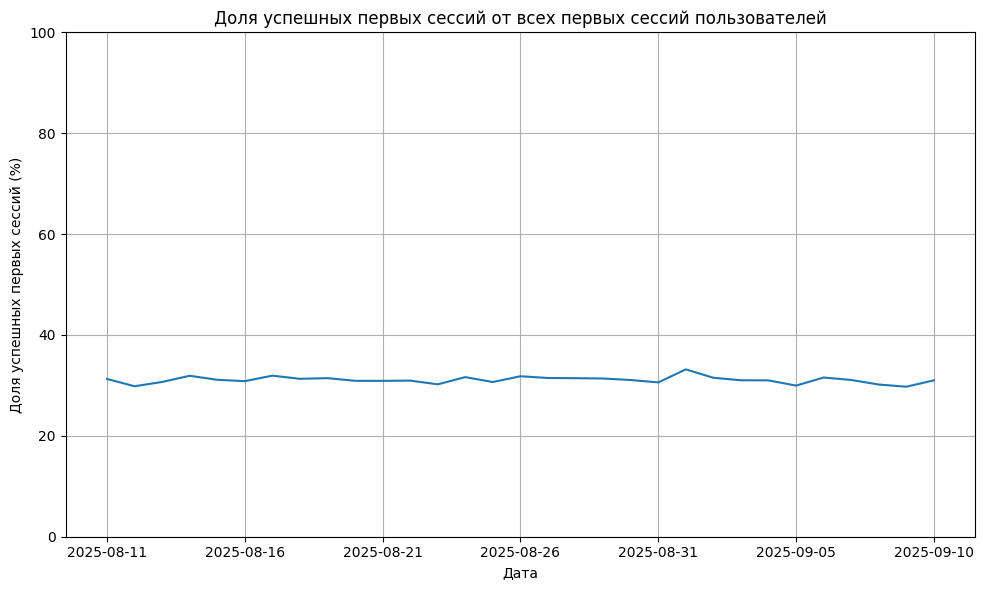

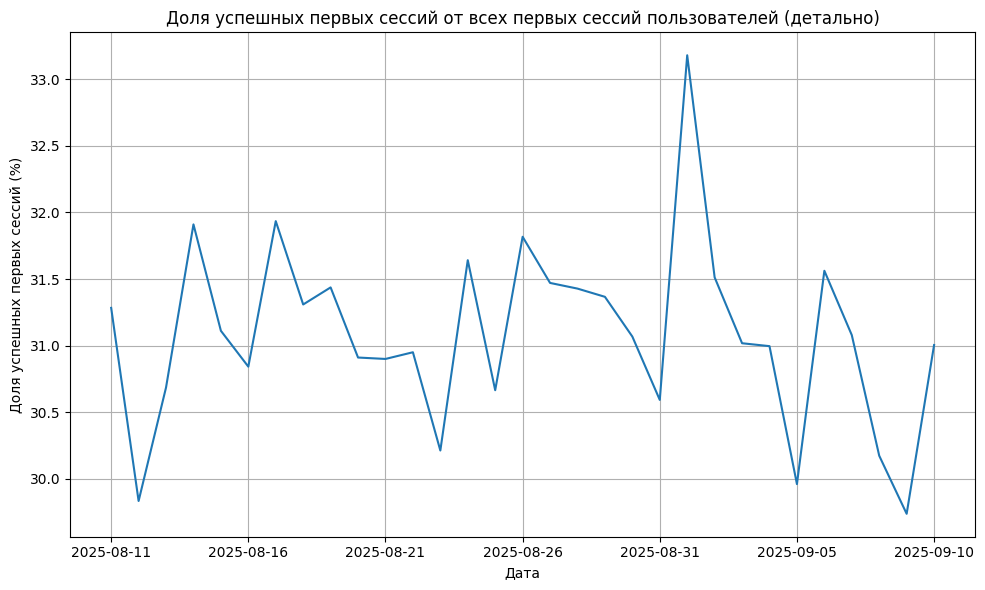

In [9]:
# Количество успешных первых сессий по дням
successful_first_sessions = sessions_history[
    (sessions_history['good_session'] == 1) & 
    (sessions_history['session_number'] == 1)
].groupby('session_date')['session_id'].count()

# Общее количество первых сессий по дням
total_first_sessions = sessions_history[
    sessions_history['session_number'] == 1
].groupby('session_date')['session_id'].count()

# Доля успешных сессий
share_successful_sessions = (successful_first_sessions / total_first_sessions) * 100

def plot_share(limit_y=True):
    plt.figure(figsize=(10, 6))
    share_successful_sessions.plot(
        kind='line'
    )
    plt.xlabel('Дата')
    plt.ylabel('Доля успешных первых сессий (%)')
    plt.grid(True)
    if limit_y:
        plt.title('Доля успешных первых сессий от всех первых сессий пользователей')
        plt.ylim(0, 100)
    else:
        plt.title('Доля успешных первых сессий от всех первых сессий пользователей (детально)')
    plt.tight_layout()
    plt.show()

# График с ограничением по оси Y, чтобы не искажать данные
plot_share(limit_y=True)

# График без ограничения для более детального представления
plot_share(limit_y=False)

Доля успешных первых сессий колеблется вокруг 31%, не обладает явным трендом и поэтому трудно сделать какие-либо выводы. Метрика стабильна.

<a id="подготовка"></a>
## 2 Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

### 2.1 Расчёт размера выборки
Установим в коде ниже следующие параметры эксперимента:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

In [10]:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")


Необходимый размер выборки для каждой группы: 41040


### 2.2 Расчёт длительности A/B-теста

Используя данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения, рассчитаем длительность теста, разделив одно на другое.

In [11]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


<a id="мониторинг"></a>
## 3 Мониторинг А/В-теста

### 3.1 Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

Загрузим файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

In [12]:
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


Рассчитаем процентную разницу в количестве пользователей в группах A и B.
Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Разница в количестве пользователей в группах A и B: 0.74%


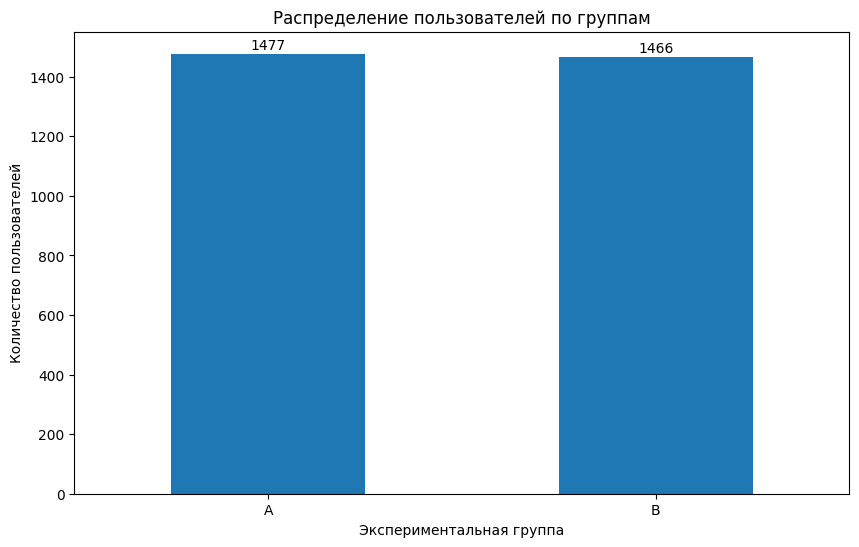

In [13]:
users_by_groups = sessions_test_part.groupby('test_group')['user_id'].nunique()

p = round(100 * abs(users_by_groups['A'] - users_by_groups['B']) / users_by_groups['A'], 2)
print(f"Разница в количестве пользователей в группах A и B: {p}%")

plt.figure(figsize=(10, 6))
ax = users_by_groups.plot(kind='bar',
                     title='Распределение пользователей по группам',
                     xlabel='Экспериментальная группа',
                     ylabel='Количество пользователей',
                     rot=0)

for i, v in enumerate(users_by_groups.values):
    ax.text(i, v + 5, str(v), va='bottom', ha='center')

plt.show()

Разница между размерами групп незначительна (0.74%). Группы сбалансированы, тест можно продолжать.

### 3.2 Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [14]:
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(group_a) & set(group_b))
intersection

[]

Пересечения в группах отсутствуют.

### 3.3 Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.


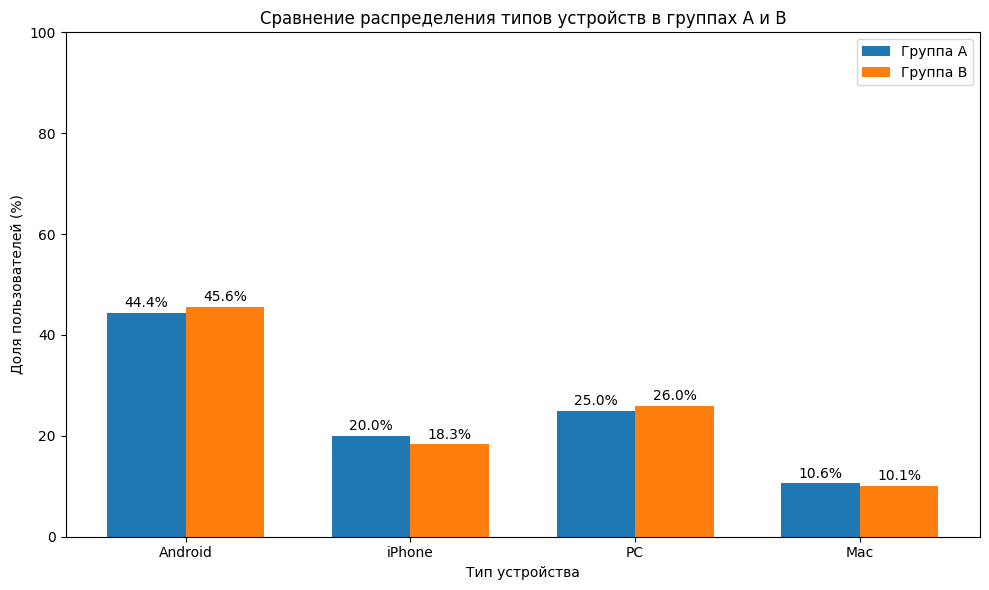

In [15]:
groups = ['A', 'B']
devices = sessions_test_part['device'].unique()

data = {}
for group in groups:
    group_data = sessions_test_part[sessions_test_part['test_group'] == group]
    device_counts = group_data.groupby('device')['user_id'].nunique()
    total_users = group_data['user_id'].nunique()
    data[group] = (device_counts / total_users * 100).reindex(devices, fill_value=0)

x = range(len(devices))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar([i - width/2 for i in x], data['A'].values, width, label='Группа A')
bars2 = ax.bar([i + width/2 for i in x], data['B'].values, width, label='Группа B')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom')

ax.set_xlabel('Тип устройства')
ax.set_ylabel('Доля пользователей (%)')
ax.set_title('Сравнение распределения типов устройств в группах A и B')
ax.set_xticks(x)
ax.set_xticklabels(devices)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

В целом, распределение устройств в группах A и B совпадает.

### 3.4 Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

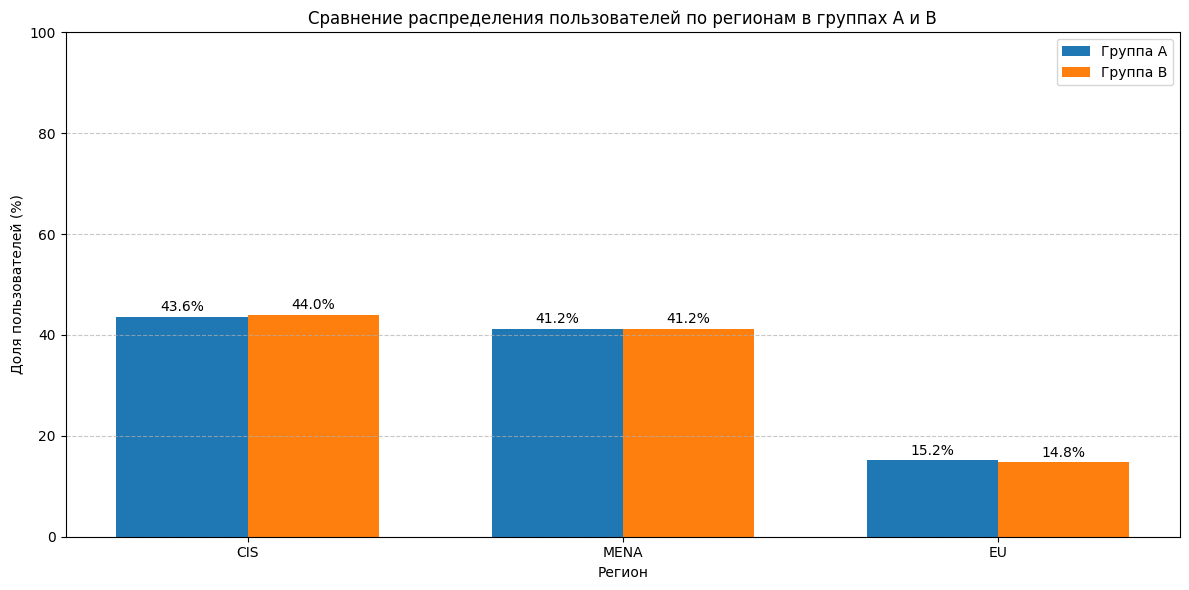

In [16]:
regions = sessions_test_part['region'].unique()

data = {}
for group in groups:
    group_data = sessions_test_part[sessions_test_part['test_group'] == group]
    region_counts = group_data.groupby('region')['user_id'].nunique()
    total_users = group_data['user_id'].nunique()
    data[group] = (region_counts / total_users * 100).reindex(regions, fill_value=0)

x = range(len(regions))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar([i - width/2 for i in x], data['A'].values, width, label='Группа A')
bars2 = ax.bar([i + width/2 for i in x], data['B'].values, width, label='Группа B')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom')

ax.set_xlabel('Регион')
ax.set_ylabel('Доля пользователей (%)')
ax.set_title('Сравнение распределения пользователей по регионам в группах A и B')
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Распределение регионов в группах A и B практически идентично.

### 3.5 Вывод после проверки A/B-теста

1) Различие в количестве пользователей в двух группах составляет 0.74%, что вполне приемлемо.

2) Пересечение пользователей из тестовой и контрольной групп не обнаружено. Выборки независимы.

3) Равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным (устройствам и регионам) сохраняется.

Следовательно, A/B-тест проходит корректно.

<a id="проверка"></a>
## 4 Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

### 4.1 Получение результатов теста и подсчёт основной метрики

Загрузим CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

In [17]:
sessions_test = pd.read_csv('sessions_project_test.csv')

В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [18]:
sessions_test['good_session'] = sessions_test['page_counter'].apply(lambda x: 1 if x >= 4 else 0)

Проверим изменения.

In [19]:
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


Узнаем длительность эксперимента.

In [20]:
sessions_test['session_date'].nunique()

20

### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик
Нулевая гипотеза: при внедрении нового алгоритма доля успешных сессий не изменилась.

Альтернативная гипотеза: при внедрении нового алгоритма доля успешных сессий увеличилась.

Прокси-метрики:
- Время на сайте - если контент интереснее, пользователь проводит больше времени.
- Количество лайков / реакций - прямое выражение удовлетворённости.

Барьерные метрики:
- Частота выхода из приложения (отток) - новый алгоритм не должен раздражать пользователей.
- Количество жалоб / негативных реакций.

### 4.3 Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [21]:
successful_sessions = sessions_test[
    (sessions_test['good_session'] == 1) & 
    (sessions_test['session_number'] == 1)
].groupby('test_group')['session_id'].count()

total_sessions = sessions_test[
    sessions_test['session_number'] == 1
].groupby('test_group')['session_id'].count()

share_successful_sessions = round((successful_sessions / total_sessions) * 100, 3)
print(f'Доля успешных первых сессий для выборок A и B (%): \n{share_successful_sessions}\n')

diff = round(share_successful_sessions['B'] - share_successful_sessions['A'], 3)
print(f"Разница в доле успешных первых сессий между группами A и B: {diff}%")

Доля успешных первых сессий для выборок A и B (%): 
test_group
A    31.572
B    31.467
Name: session_id, dtype: float64

Разница в доле успешных первых сессий между группами A и B: -0.105%


### 4.4 Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

In [22]:
n_a, n_b = total_sessions
m_a, m_b = successful_sessions

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)
p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение. Статистически значимых изменений НЕТ.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза НЕ находит подтверждения. Статистически значиме изменения ЕСТЬ.')

pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза находит подтверждение. Статистически значимых изменений НЕТ.


<a id="вывод"></a>
## 5 Вывод по результатам A/B-эксперимента

Характеристики проведённого эксперимента:
- Уровень значимости - 0.05,
- Вероятность ошибки второго рода - 0.2,
- Мощность теста - 0.8,
- Минимальный детектируемый эффект, или MDE, - 3%.

Количество задействованных пользователей:
- группа А - 1477,
- группа В - 1466.

Длительность эксперимента: 20 дней.

После внедрения нового алгоритма рекомендаций ключевая метрика снизилась на 0.105%.

p-value получилось 0.578.

Новый алгоритм рекомендаций НЕ показал статистически значимого улучшения целевой метрики.

Рекомендация: отклонить новый алгоритм, продолжить использование текущего.

Дополнительно можно:
- обсудить с командой, почему ожидался эффект 3%,
- пересмотреть гипотезы о том, как алгоритм должен влиять на метрики,
- проанализировать другие метрики (возможно, эффект есть где-то ещё).